In [3]:
import pandas as pd
import numpy as np
df1=pd.read_csv("/content/PS_20174392719_1491204439457_log 2.csv")
print(df1)





        step      type      amount     nameOrig  oldbalanceOrg  \
0          1   PAYMENT     9839.64  C1231006815      170136.00   
1          1   PAYMENT     1864.28  C1666544295       21249.00   
2          1  TRANSFER      181.00  C1305486145         181.00   
3          1  CASH_OUT      181.00   C840083671         181.00   
4          1   PAYMENT    11668.14  C2048537720       41554.00   
...      ...       ...         ...          ...            ...   
124452    11  TRANSFER  1428231.23   C672404201        5689.00   
124453    11   PAYMENT    24444.57    C50554983       95761.29   
124454    11   PAYMENT     9495.13   C516667550       71316.72   
124455    11   PAYMENT     6644.65   C244871179        3025.00   
124456    11   CASH_IN    82501.87          NaN            NaN   

        newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0            160296.36  M1979787155             0.0            0.00      0.0   
1             19384.72  M2044282225            

In [4]:
df1=pd.read_csv("/content/PS_20174392719_1491204439457_log 2.csv")
df1.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [5]:
print(df1.isnull().sum(), "\n")




step              0
type              0
amount            0
nameOrig          1
oldbalanceOrg     1
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64 



In [6]:
df1.dropna(inplace=True)     #inplace make changes in original data

In [7]:
print(df1.isnull().sum(), "\n")

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64 



In [8]:
df1.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,124456.000000,1.244560e+05,1.244560e+05,1.244560e+05,1.244560e+05,1.244560e+05,124456.000000,124456.0
mean,8.920928,1.773621e+05,9.047501e+05,9.209941e+05,9.004621e+05,1.185246e+06,0.000964,0.0
std,1.857026,3.440316e+05,2.850751e+06,2.887776e+06,2.391423e+06,2.749984e+06,0.031037,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,8.000000,1.059714e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,9.000000,5.785164e+04,2.009300e+04,0.000000e+00,2.830632e+04,7.527365e+04,0.000000,0.0
75%,10.000000,2.180577e+05,1.952794e+05,2.222311e+05,6.424462e+05,1.097218e+06,0.000000,0.0
max,11.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.400874e+07,3.894623e+07,1.000000,0.0


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124456 entries, 0 to 124455
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            124456 non-null  int64  
 1   type            124456 non-null  object 
 2   amount          124456 non-null  float64
 3   nameOrig        124456 non-null  object 
 4   oldbalanceOrg   124456 non-null  float64
 5   newbalanceOrig  124456 non-null  float64
 6   nameDest        124456 non-null  object 
 7   oldbalanceDest  124456 non-null  float64
 8   newbalanceDest  124456 non-null  float64
 9   isFraud         124456 non-null  float64
 10  isFlaggedFraud  124456 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 11.4+ MB


In [10]:
print(df1["type"].value_counts(), "\n")
           #or
#print(df1.type.value_counts())


type
PAYMENT     48078
CASH_OUT    39349
CASH_IN     25208
TRANSFER    10650
DEBIT        1171
Name: count, dtype: int64 



Coorealtion--shows realtionship...realionship starts from -1 to +1

In [14]:
coorealtion=df1.select_dtypes(include=['number']).corr()
print(coorealtion["isFraud"])

step             -0.050677
amount            0.035281
oldbalanceOrg    -0.003552
newbalanceOrig   -0.009606
oldbalanceDest   -0.008841
newbalanceDest   -0.005916
isFraud           1.000000
isFlaggedFraud         NaN
Name: isFraud, dtype: float64


Coorelation Matrix---shows relation in chart

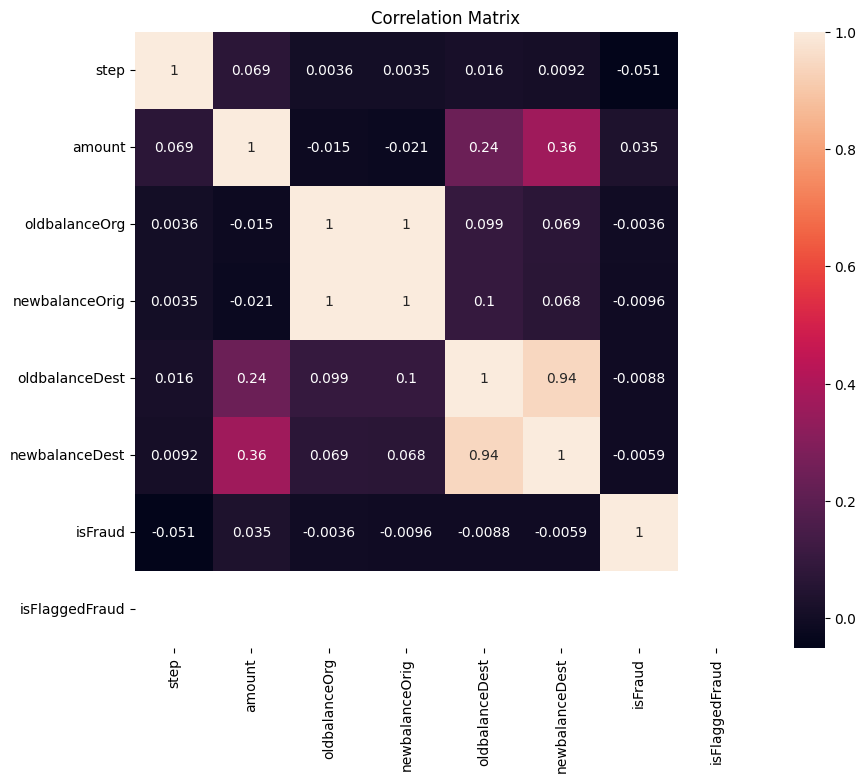

In [18]:
import pandas as pd
import seaborn as sns           #only used for visulaization
import matplotlib.pyplot as plt #only used for visualization


plt.figure(figsize=(10,8))            #size of chart by our choice
sns.heatmap(coorealtion,  annot=True) #coorelation chart is called as heatmap and annot is used to display values
plt.title("Correlation Matrix")       #to give the title by our choice
plt.show()



In [16]:
df1["type"]=df1["type"].map({"CASH_OUT":1, "PAYMENT":2,
                             "CASH_IN":3, "TRANSFER":4,
                             "DEBIT":5})
df1["isFraud"]=df1["isFraud"].map({0: "No Fraud",1: "Fraud"})
print(df1.head())

   step  type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1     2   9839.64  C1231006815       170136.0       160296.36   
1     1     2   1864.28  C1666544295        21249.0        19384.72   
2     1     4    181.00  C1305486145          181.0            0.00   
3     1     1    181.00   C840083671          181.0            0.00   
4     1     2  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0  No Fraud             0.0  
1  M2044282225             0.0             0.0  No Fraud             0.0  
2   C553264065             0.0             0.0     Fraud             0.0  
3    C38997010         21182.0             0.0     Fraud             0.0  
4  M1230701703             0.0             0.0  No Fraud             0.0  


Train a model to classify fraud and non fraud transactions.

In [19]:
# splitting the data
x=np.array(df1[["type","amount","oldbalanceOrg","newbalanceOrig"]]) #taking input
y=np.array(df1["isFraud"])   #value which we have to predict

splitting the data into two parts

In [20]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest= train_test_split(x,y, test_size=0.20, random_state=42)

#test size define that % of data will go for testing and rest for training
#random state value defines that set of will be shuffled
#model is just a variable

Training a model

In [21]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(xtrain, ytrain)       #just train the model
print(model.score(xtest, ytest)) #test will give value and accuracy

0.9988751406074241


In [22]:
#prediction
#features= [type,amount,oldbalanceOrg,newbalanceOrig]
features=np.array([[4,9000.60,9000.60,0.0]])
print(model.predict(features))

['No Fraud']


Line plot(trend analysis)
use case: time series, stock prices, growth trends

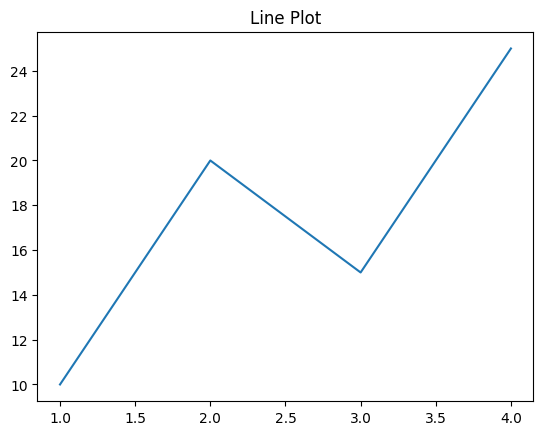

In [23]:
x=[1,2,3,4]
y=[10,20,15,25]

plt.plot(x,y)
plt.title("Line Plot")
plt.show()

Bar Plot (category comparison)
use cases: sales by region, product comparison

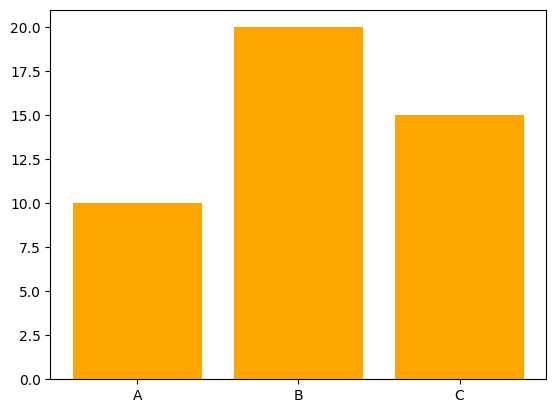

In [24]:
plt.bar(['A','B','C'], [10,20,15],color='orange')
plt.show()